# Validation-only 3D persistence and hysteresis ablation

## tl;dr

The adjacent-slice 2.5D experiment failed its validation gate. Its main useful result was low empty-slice false-positive rate, while the earlier intensity-normalized model retained much stronger patient and small-lesion recall. This notebook therefore performs **no training**. It applies validation-only volumetric connected-component and hysteresis rules to the frozen intensity-model probabilities.

The decision is whether simple 3D continuity can preserve the intensity model's recall while reducing scattered false positives. The test split remains locked throughout.

Expected outputs are written to `Practice/validation_3d_postprocessing_outputs`.

## Context & Methods

### Key assumptions

- `Practice/` and the verified manifest remain authoritative.
- The intensity model checkpoint, preprocessing, manifest hash, and validation patients are unchanged.
- Post-processing configurations are selected only on validation data.
- Test images are never opened.
- This is an ablation gate, not a final unbiased performance estimate.

### Decision targets

The selected configuration should retain or improve the intensity model's mean patient Dice, keep volume 104 useful, recover volume 116, preserve small-lesion detection, and reduce both missed-positive slices and empty-slice false positives.

In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import platform
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage
import torch
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
INTENSITY_OUTPUT_DIR = PROJECT_ROOT / "Practice" / "intensity_robustness_outputs"
CONTEXT_OUTPUT_DIR = PROJECT_ROOT / "Practice" / "context_2_5d_outputs"
OUTPUT_DIR = PROJECT_ROOT / "Practice" / "validation_3d_postprocessing_outputs"
CACHE_DIR = OUTPUT_DIR / "probability_cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
BATCH_SIZE = 16
NUM_WORKERS = 0
ORGAN_Z_CLIP = 3.0
EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)
CHECKPOINT_PATH = INTENSITY_OUTPUT_DIR / "patient_aware_best.pth"

TARGETS = {
    "mean_patient_dice": 0.406915,
    "volume_104_dice": 0.50,
    "volume_116_dice": 0.05,
    "q1_detected_pct": 45.0,
    "positive_predicted_empty_pct": 20.0,
    "empty_slice_false_positive_pct": 15.0,
}

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__}")
print(f"OS: {platform.platform()} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Outputs: {OUTPUT_DIR}")

Python 3.11.15 | PyTorch 2.6.0+cu124
OS: Windows-10-10.0.26200-SP0 | CUDA: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\validation_3d_postprocessing_outputs


### 1. Process and decision map

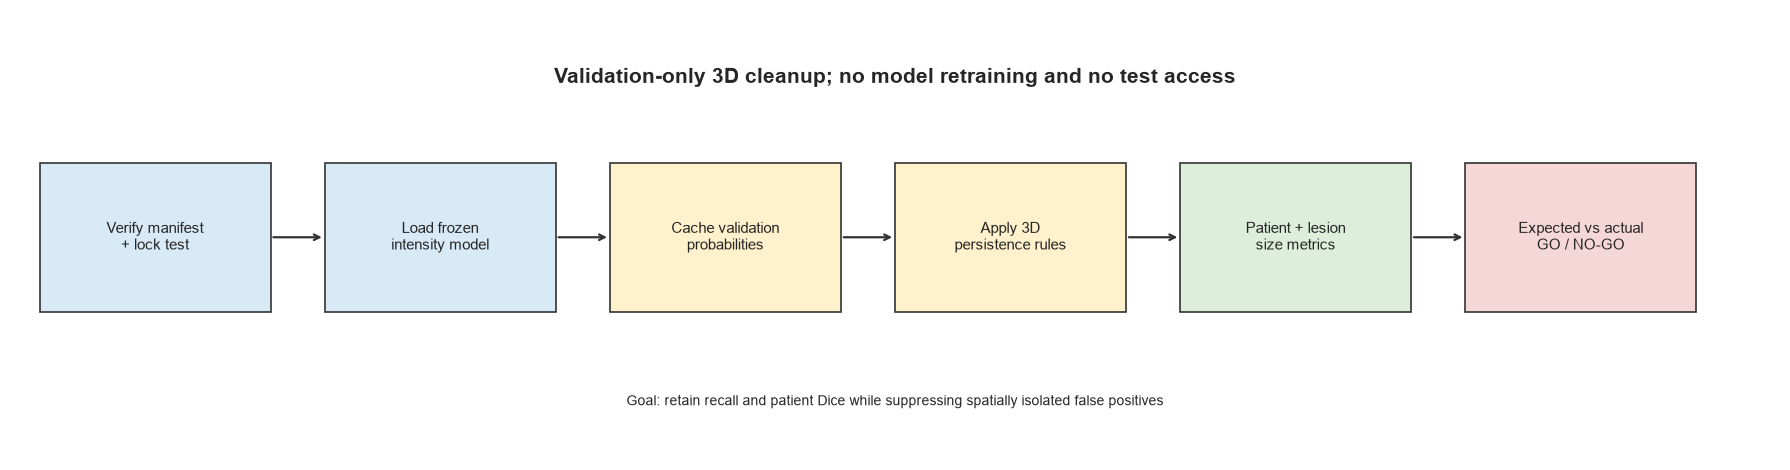

In [2]:
fig, axis = plt.subplots(figsize=(18, 4.8))
axis.set_xlim(0, 18); axis.set_ylim(0, 5); axis.axis("off")
steps = [
    (0.3, "Verify manifest\n+ lock test", "#D9EAF7"),
    (3.2, "Load frozen\nintensity model", "#D9EAF7"),
    (6.1, "Cache validation\nprobabilities", "#FFF1CC"),
    (9.0, "Apply 3D\npersistence rules", "#FFF1CC"),
    (11.9, "Patient + lesion\nsize metrics", "#DDEEDB"),
    (14.8, "Expected vs actual\nGO / NO-GO", "#F6D7D7"),
]
for x, label, color in steps:
    axis.add_patch(plt.Rectangle(
        (x, 1.65), 2.35, 1.65, facecolor=color,
        edgecolor="#333333", linewidth=1.2
    ))
    axis.text(x + 1.175, 2.475, label, ha="center", va="center", fontsize=11)
for (left, _, _), (right, _, _) in zip(steps[:-1], steps[1:]):
    axis.annotate("", xy=(right, 2.475), xytext=(left + 2.35, 2.475),
                  arrowprops={"arrowstyle": "->", "linewidth": 1.6, "color": "#333333"})
axis.text(9, 4.25, "Validation-only 3D cleanup; no model retraining and no test access",
          ha="center", va="center", fontsize=15, weight="bold")
axis.text(9, 0.65, "Goal: retain recall and patient Dice while suppressing spatially isolated false positives",
          ha="center", va="center", fontsize=10)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "postprocessing_process_map.png", dpi=160, bbox_inches="tight")
plt.show()

## Data

### 2. Verify provenance, patient isolation, and the locked test boundary

In [3]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

manifest_hash = sha256_file(MANIFEST_PATH)
checkpoint_hash = sha256_file(CHECKPOINT_PATH)
assert manifest_hash == EXPECTED_MANIFEST_SHA256
assert CHECKPOINT_PATH.is_file()

manifest = pd.read_csv(MANIFEST_PATH)
assert len(manifest) == 58_638
assert manifest["sample_id"].is_unique
assert manifest["verification_status"].eq("verified").all()
assert manifest["manual_spatial_status"].eq("approved").all()

try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError as exc:
    print(f"PASS: test split locked: {exc}")
else:
    raise AssertionError("Test split opened without explicit authorization.")

volume_sets = {
    split: set(manifest.loc[manifest["split"].eq(split), "volume_id"])
    for split in ("train", "val", "test")
}
assert volume_sets["train"].isdisjoint(volume_sets["val"])
assert volume_sets["train"].isdisjoint(volume_sets["test"])
assert volume_sets["val"].isdisjoint(volume_sets["test"])

provenance = pd.DataFrame([{
    "manifest_sha256": manifest_hash,
    "checkpoint_sha256": checkpoint_hash,
    "manifest_rows": len(manifest),
    "validation_volumes": len(volume_sets["val"]),
    "test_images_accessed": False,
}])
display(provenance)
print("PASS: frozen manifest, checkpoint identity, and patient isolation verified.")

PASS: test split locked: Test data access is locked. Pass allow_test=True only for the one-time held-out evaluation after model decisions are frozen.


,manifest_sha256,checkpoint_sha256,manifest_rows,validation_volumes,test_images_accessed
0,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...,5f18223c0f618d45d1433dc4a48d950fdea8a039db9ea5...,58638,13,False


PASS: frozen manifest, checkpoint identity, and patient isolation verified.


### 3. Load the exact intensity-normalized validation pipeline

In [4]:
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet

def organ_robust_normalize(image: np.ndarray, organ_mask: np.ndarray) -> np.ndarray:
    image = np.asarray(image, dtype=np.float32)
    organ_mask = np.asarray(organ_mask, dtype=bool)
    reference = image[organ_mask]
    if reference.size < 32:
        reference = image[image > 0]
    if reference.size < 32:
        reference = image.reshape(-1)
    center = float(np.median(reference))
    q25, q75 = np.percentile(reference, [25, 75])
    robust_sigma = float((q75 - q25) / 1.349)
    if not np.isfinite(robust_sigma) or robust_sigma < 1e-3:
        robust_sigma = max(float(np.std(reference)), 1e-3)
    normalized = np.clip((image - center) / robust_sigma, -ORGAN_Z_CLIP, ORGAN_Z_CLIP)
    return ((normalized + ORGAN_Z_CLIP) / (2 * ORGAN_Z_CLIP)).astype(np.float32)


class OrganNormalizedDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset
        self.rows = base_dataset.rows

    def __len__(self):
        return len(self.base)

    def __getitem__(self, index):
        sample = self.base[index]
        image = sample["image"][0].numpy()
        with Image.open(self.rows[index]["organ_mask_path"]) as handle:
            organ = np.asarray(handle.convert("L"), dtype=np.uint8) > 0
        sample["image"] = torch.from_numpy(
            organ_robust_normalize(image, organ)[None]
        ).float()
        return sample


val_base_dataset = VerifiedManifestDataset(
    MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
    target="tumor", transform=None, validate_paths=True,
)
val_dataset = OrganNormalizedDataset(val_base_dataset)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
payload = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
assert payload["manifest_sha256"] == manifest_hash
assert payload["configuration"]["preprocessing_strategy"] == (
    "organ_robust_zscore_clip3_gamma_noise_v1"
)
model = MobileNetV2UNet(in_channels=1, out_channels=1, pretrained=False).to(device)
model.load_state_dict(payload["model_state"])
model.eval()
print(f"Validation slices: {len(val_dataset):,} | checkpoint epoch: {payload['epoch']}")

Validation slices: 10,685 | checkpoint epoch: 8


### 4. Cache validation probabilities by volume

Probabilities are quantized to 8-bit only for this post-processing ablation. This bounds disk usage and makes reruns deterministic. The cache is invalidated if either the manifest or checkpoint hash changes.

In [5]:
cache_metadata_path = CACHE_DIR / "cache_metadata.json"
expected_cache_metadata = {
    "manifest_sha256": manifest_hash,
    "checkpoint_sha256": checkpoint_hash,
    "quantization": "round(probability * 255) uint8",
    "validation_slices": len(val_dataset),
}
cache_valid = False
if cache_metadata_path.is_file():
    cache_valid = json.loads(cache_metadata_path.read_text()) == expected_cache_metadata
    cache_valid = cache_valid and all(
        (CACHE_DIR / f"volume_{int(volume_id):03d}.npz").is_file()
        for volume_id in sorted(volume_sets["val"])
    )

if not cache_valid:
    for old_cache in CACHE_DIR.glob("volume_*.npz"):
        old_cache.unlink()

    buffers = {}
    started = time.perf_counter()
    with torch.inference_mode():
        for batch_index, batch in enumerate(val_loader, start=1):
            probabilities = torch.sigmoid(
                model(batch["image"].to(device, non_blocking=True))
            ).cpu().numpy()[:, 0]
            masks = (batch["mask"].numpy()[:, 0] >= 0.5)
            for index, sample_id in enumerate(batch["sample_id"]):
                volume_id = int(batch["volume_id"][index])
                bucket = buffers.setdefault(
                    volume_id,
                    {"probability": [], "truth": [], "slice_index": [], "sample_id": []},
                )
                bucket["probability"].append(
                    np.rint(np.clip(probabilities[index], 0, 1) * 255).astype(np.uint8)
                )
                bucket["truth"].append(masks[index].astype(np.uint8))
                bucket["slice_index"].append(int(batch["slice_index"][index]))
                bucket["sample_id"].append(str(sample_id))
            if batch_index % 100 == 0:
                print(f"inference batches: {batch_index}/{len(val_loader)}")

    for volume_id, bucket in buffers.items():
        order = np.argsort(bucket["slice_index"])
        np.savez_compressed(
            CACHE_DIR / f"volume_{volume_id:03d}.npz",
            probability=np.stack(bucket["probability"])[order],
            truth=np.stack(bucket["truth"])[order],
            slice_index=np.asarray(bucket["slice_index"], dtype=np.int32)[order],
            sample_id=np.asarray(bucket["sample_id"], dtype="U80")[order],
        )
    cache_metadata_path.write_text(json.dumps(expected_cache_metadata, indent=2))
    print(f"Probability cache created in {(time.perf_counter()-started)/60:.1f} minutes.")
else:
    print("PASS: reusing probability cache with matching manifest and checkpoint hashes.")

cache_profile = []
for path in sorted(CACHE_DIR.glob("volume_*.npz")):
    with np.load(path) as data:
        cache_profile.append({
            "volume_id": int(path.stem.split("_")[-1]),
            "slices": len(data["slice_index"]),
            "positive_slices": int((data["truth"].sum(axis=(1, 2)) > 0).sum()),
            "cache_mb": path.stat().st_size / 1024**2,
        })
cache_profile = pd.DataFrame(cache_profile)
assert cache_profile["slices"].sum() == len(val_dataset)
cache_profile.to_csv(OUTPUT_DIR / "cache_coverage.csv", index=False)
display(cache_profile)

inference batches: 100/668
inference batches: 200/668
inference batches: 300/668
inference batches: 400/668
inference batches: 500/668
inference batches: 600/668
Probability cache created in 1.8 minutes.


,volume_id,slices,positive_slices,cache_mb
0,104,781,122,1.279425
1,105,986,0,1.959619
2,106,771,0,1.459316
3,107,771,71,1.769025
4,108,856,202,2.163343
5,109,756,131,1.769650
6,110,816,130,2.379885
7,111,761,92,1.578151
8,112,751,26,1.634052
9,113,836,135,1.607246


## Results

### 5. Define bounded 3D persistence configurations

In [6]:
configurations = pd.DataFrame([
    {"config": "raw_t050", "low": 0.50, "high": 0.50, "min_voxels": 0, "min_z_span": 1},
    {"config": "raw_t030", "low": 0.30, "high": 0.30, "min_voxels": 0, "min_z_span": 1},
    {"config": "raw_t020", "low": 0.20, "high": 0.20, "min_voxels": 0, "min_z_span": 1},
    {"config": "h20_50_v16_z1", "low": 0.20, "high": 0.50, "min_voxels": 16, "min_z_span": 1},
    {"config": "h20_50_v64_z1", "low": 0.20, "high": 0.50, "min_voxels": 64, "min_z_span": 1},
    {"config": "h20_50_v16_z2", "low": 0.20, "high": 0.50, "min_voxels": 16, "min_z_span": 2},
    {"config": "h20_50_v64_z2", "low": 0.20, "high": 0.50, "min_voxels": 64, "min_z_span": 2},
    {"config": "h30_50_v16_z1", "low": 0.30, "high": 0.50, "min_voxels": 16, "min_z_span": 1},
    {"config": "h30_50_v64_z1", "low": 0.30, "high": 0.50, "min_voxels": 64, "min_z_span": 1},
    {"config": "h30_50_v16_z2", "low": 0.30, "high": 0.50, "min_voxels": 16, "min_z_span": 2},
    {"config": "h30_50_v64_z2", "low": 0.30, "high": 0.50, "min_voxels": 64, "min_z_span": 2},
    {"config": "h30_65_v64_z2", "low": 0.30, "high": 0.65, "min_voxels": 64, "min_z_span": 2},
])
display(configurations)

structure_3d = ndimage.generate_binary_structure(rank=3, connectivity=1)

def postprocess_volume(probability, low, high, min_voxels, min_z_span):
    candidate = probability >= low
    if min_voxels <= 0 and min_z_span <= 1 and high <= low:
        return candidate
    labels, component_count = ndimage.label(candidate, structure=structure_3d)
    if component_count == 0:
        return np.zeros_like(candidate, dtype=bool)
    sizes = np.bincount(labels.ravel())
    high_labels = np.unique(labels[probability >= high])
    keep = np.zeros(component_count + 1, dtype=bool)
    for component_label in high_labels:
        if component_label == 0 or sizes[component_label] < min_voxels:
            continue
        locations = np.where(labels == component_label)
        z_span = int(locations[0].max() - locations[0].min() + 1)
        if z_span >= min_z_span:
            keep[component_label] = True
    return keep[labels]

,config,low,high,min_voxels,min_z_span
0,raw_t050,0.5,0.50,0,1
1,raw_t030,0.3,0.30,0,1
2,raw_t020,0.2,0.20,0,1
3,h20_50_v16_z1,0.2,0.50,16,1
4,h20_50_v64_z1,0.2,0.50,64,1
5,h20_50_v16_z2,0.2,0.50,16,2
6,h20_50_v64_z2,0.2,0.50,64,2
7,h30_50_v16_z1,0.3,0.50,16,1
8,h30_50_v64_z1,0.3,0.50,64,1
9,h30_50_v16_z2,0.3,0.50,16,2


### 6. Evaluate every configuration at patient, slice, and lesion-size grain

In [7]:
all_patient_rows = []
all_slice_rows = []
summary_rows = []

for config in configurations.to_dict("records"):
    patient_rows = []
    slice_rows = []
    global_intersection = global_predicted = global_true = 0
    for volume_id in sorted(volume_sets["val"]):
        with np.load(CACHE_DIR / f"volume_{int(volume_id):03d}.npz") as data:
            probability = data["probability"].astype(np.float32) / 255.0
            truth = data["truth"].astype(bool)
            prediction = postprocess_volume(
                probability, config["low"], config["high"],
                config["min_voxels"], config["min_z_span"],
            )
            intersection_by_slice = (prediction & truth).sum(axis=(1, 2))
            predicted_by_slice = prediction.sum(axis=(1, 2))
            true_by_slice = truth.sum(axis=(1, 2))
            inter = int(intersection_by_slice.sum())
            pred = int(predicted_by_slice.sum())
            true = int(true_by_slice.sum())
            global_intersection += inter
            global_predicted += pred
            global_true += true
            positive = true_by_slice > 0
            empty = ~positive
            patient_rows.append({
                "config": config["config"], "volume_id": int(volume_id),
                "micro_dice": (2 * inter + 1e-6) / (pred + true + 1e-6),
                "true_pixels": true, "predicted_pixels": pred,
                "positive_slices": int(positive.sum()),
                "positive_slice_recall": float(
                    (intersection_by_slice[positive] > 0).mean()
                ) if positive.any() else 0.0,
                "positive_predicted_empty_pct": float(
                    100 * (predicted_by_slice[positive] == 0).mean()
                ) if positive.any() else 0.0,
                "empty_slice_false_positive_pct": float(
                    100 * (predicted_by_slice[empty] > 0).mean()
                ) if empty.any() else 0.0,
            })
            for idx in range(len(data["slice_index"])):
                intersection = int(intersection_by_slice[idx])
                predicted = int(predicted_by_slice[idx])
                actual = int(true_by_slice[idx])
                slice_rows.append({
                    "config": config["config"],
                    "sample_id": str(data["sample_id"][idx]),
                    "volume_id": int(volume_id),
                    "slice_index": int(data["slice_index"][idx]),
                    "true_pixels": actual,
                    "predicted_pixels": predicted,
                    "intersection_pixels": intersection,
                    "dice": (2 * intersection + 1e-6) / (predicted + actual + 1e-6),
                })

    patient_frame = pd.DataFrame(patient_rows)
    slice_frame = pd.DataFrame(slice_rows)
    positive_patients = patient_frame.loc[patient_frame["true_pixels"].gt(0)]
    positive_slices = slice_frame.loc[slice_frame["true_pixels"].gt(0)].copy()
    positive_slices["size_quartile"] = pd.qcut(
        positive_slices["true_pixels"], q=4,
        labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"],
        duplicates="drop",
    )
    q1 = positive_slices.loc[positive_slices["size_quartile"].eq("Q1 smallest")]
    empty_slices = slice_frame.loc[slice_frame["true_pixels"].eq(0)]
    volume_lookup = patient_frame.set_index("volume_id")["micro_dice"]
    summary_rows.append({
        **config,
        "global_micro_dice": (2 * global_intersection + 1e-6) / (
            global_predicted + global_true + 1e-6
        ),
        "mean_patient_dice": positive_patients["micro_dice"].mean(),
        "median_patient_dice": positive_patients["micro_dice"].median(),
        "worst_patient_dice": positive_patients["micro_dice"].min(),
        "volume_104_dice": volume_lookup.get(104, np.nan),
        "volume_116_dice": volume_lookup.get(116, np.nan),
        "q1_detected_pct": 100 * (q1["intersection_pixels"] > 0).mean(),
        "positive_predicted_empty_pct": 100 * (
            positive_slices["predicted_pixels"] == 0
        ).mean(),
        "empty_slice_false_positive_pct": 100 * (
            empty_slices["predicted_pixels"] > 0
        ).mean(),
    })
    all_patient_rows.extend(patient_rows)
    all_slice_rows.extend(slice_rows)
    print(f"evaluated {config['config']}")

summary = pd.DataFrame(summary_rows)
patient_results = pd.DataFrame(all_patient_rows)
slice_results = pd.DataFrame(all_slice_rows)

higher_targets = ["mean_patient_dice", "volume_104_dice", "volume_116_dice", "q1_detected_pct"]
lower_targets = ["positive_predicted_empty_pct", "empty_slice_false_positive_pct"]
for metric in higher_targets:
    summary[f"pass_{metric}"] = summary[metric] >= TARGETS[metric]
for metric in lower_targets:
    summary[f"pass_{metric}"] = summary[metric] <= TARGETS[metric]
pass_columns = [column for column in summary if column.startswith("pass_")]
summary["targets_passed"] = summary[pass_columns].sum(axis=1)
summary["all_targets_passed"] = summary[pass_columns].all(axis=1)
summary = summary.sort_values(
    ["all_targets_passed", "targets_passed", "mean_patient_dice"],
    ascending=[False, False, False],
).reset_index(drop=True)

selected_config = summary.iloc[0]["config"]
summary.to_csv(OUTPUT_DIR / "postprocessing_configuration_summary.csv", index=False)
patient_results.to_csv(OUTPUT_DIR / "postprocessing_patient_metrics.csv", index=False)
slice_results.to_csv(OUTPUT_DIR / "postprocessing_per_slice.csv", index=False)
display(summary.style.format({
    "global_micro_dice": "{:.4f}", "mean_patient_dice": "{:.4f}",
    "volume_104_dice": "{:.4f}", "volume_116_dice": "{:.4f}",
    "q1_detected_pct": "{:.1f}%", "positive_predicted_empty_pct": "{:.1f}%",
    "empty_slice_false_positive_pct": "{:.1f}%",
}))
print(f"Selected validation configuration: {selected_config}")

evaluated raw_t050
evaluated raw_t030
evaluated raw_t020
evaluated h20_50_v16_z1
evaluated h20_50_v64_z1
evaluated h20_50_v16_z2
evaluated h20_50_v64_z2
evaluated h30_50_v16_z1
evaluated h30_50_v64_z1
evaluated h30_50_v16_z2
evaluated h30_50_v64_z2
evaluated h30_65_v64_z2


,config,low,high,min_voxels,min_z_span,global_micro_dice,mean_patient_dice,median_patient_dice,worst_patient_dice,volume_104_dice,volume_116_dice,q1_detected_pct,positive_predicted_empty_pct,empty_slice_false_positive_pct,pass_mean_patient_dice,pass_volume_104_dice,pass_volume_116_dice,pass_q1_detected_pct,pass_positive_predicted_empty_pct,pass_empty_slice_false_positive_pct,targets_passed,all_targets_passed
0,raw_t050,0.500000,0.500000,0,1,0.5462,0.4070,0.511492,0.019909,0.5866,0.0268,60.1%,8.3%,47.4%,True,True,False,True,True,False,4,False
1,h30_65_v64_z2,0.300000,0.650000,64,2,0.5268,0.3880,0.465722,0.012028,0.5822,0.0257,55.5%,18.4%,37.6%,False,True,False,True,True,False,3,False
2,h30_50_v64_z2,0.300000,0.500000,64,2,0.5224,0.3788,0.459458,0.011879,0.5819,0.0255,55.5%,18.4%,40.8%,False,True,False,True,True,False,3,False
3,h30_50_v64_z1,0.300000,0.500000,64,1,0.5222,0.3788,0.459458,0.011879,0.5811,0.0255,55.5%,18.3%,40.8%,False,True,False,True,True,False,3,False
4,h30_50_v16_z2,0.300000,0.500000,16,2,0.5163,0.3712,0.446787,0.011076,0.5756,0.0269,58.9%,12.6%,51.5%,False,True,False,True,True,False,3,False
5,h30_50_v16_z1,0.300000,0.500000,16,1,0.5157,0.3706,0.446303,0.011076,0.5742,0.0269,58.9%,12.4%,51.6%,False,True,False,True,True,False,3,False
6,raw_t030,0.300000,0.300000,0,1,0.5080,0.3634,0.437444,0.010946,0.5646,0.0284,60.5%,6.6%,67.2%,False,True,False,True,True,False,3,False
7,h20_50_v64_z2,0.200000,0.500000,64,2,0.4855,0.3441,0.401551,0.008165,0.5699,0.0254,56.3%,17.5%,51.1%,False,True,False,True,True,False,3,False
8,h20_50_v64_z1,0.200000,0.500000,64,1,0.4854,0.3441,0.401551,0.008165,0.5691,0.0254,56.3%,17.4%,51.1%,False,True,False,True,True,False,3,False
9,h20_50_v16_z2,0.200000,0.500000,16,2,0.4804,0.3390,0.392584,0.007728,0.5633,0.0272,59.7%,12.1%,60.1%,False,True,False,True,True,False,3,False


Selected validation configuration: raw_t050


### 7. Configuration frontier and expected-versus-observed dashboard

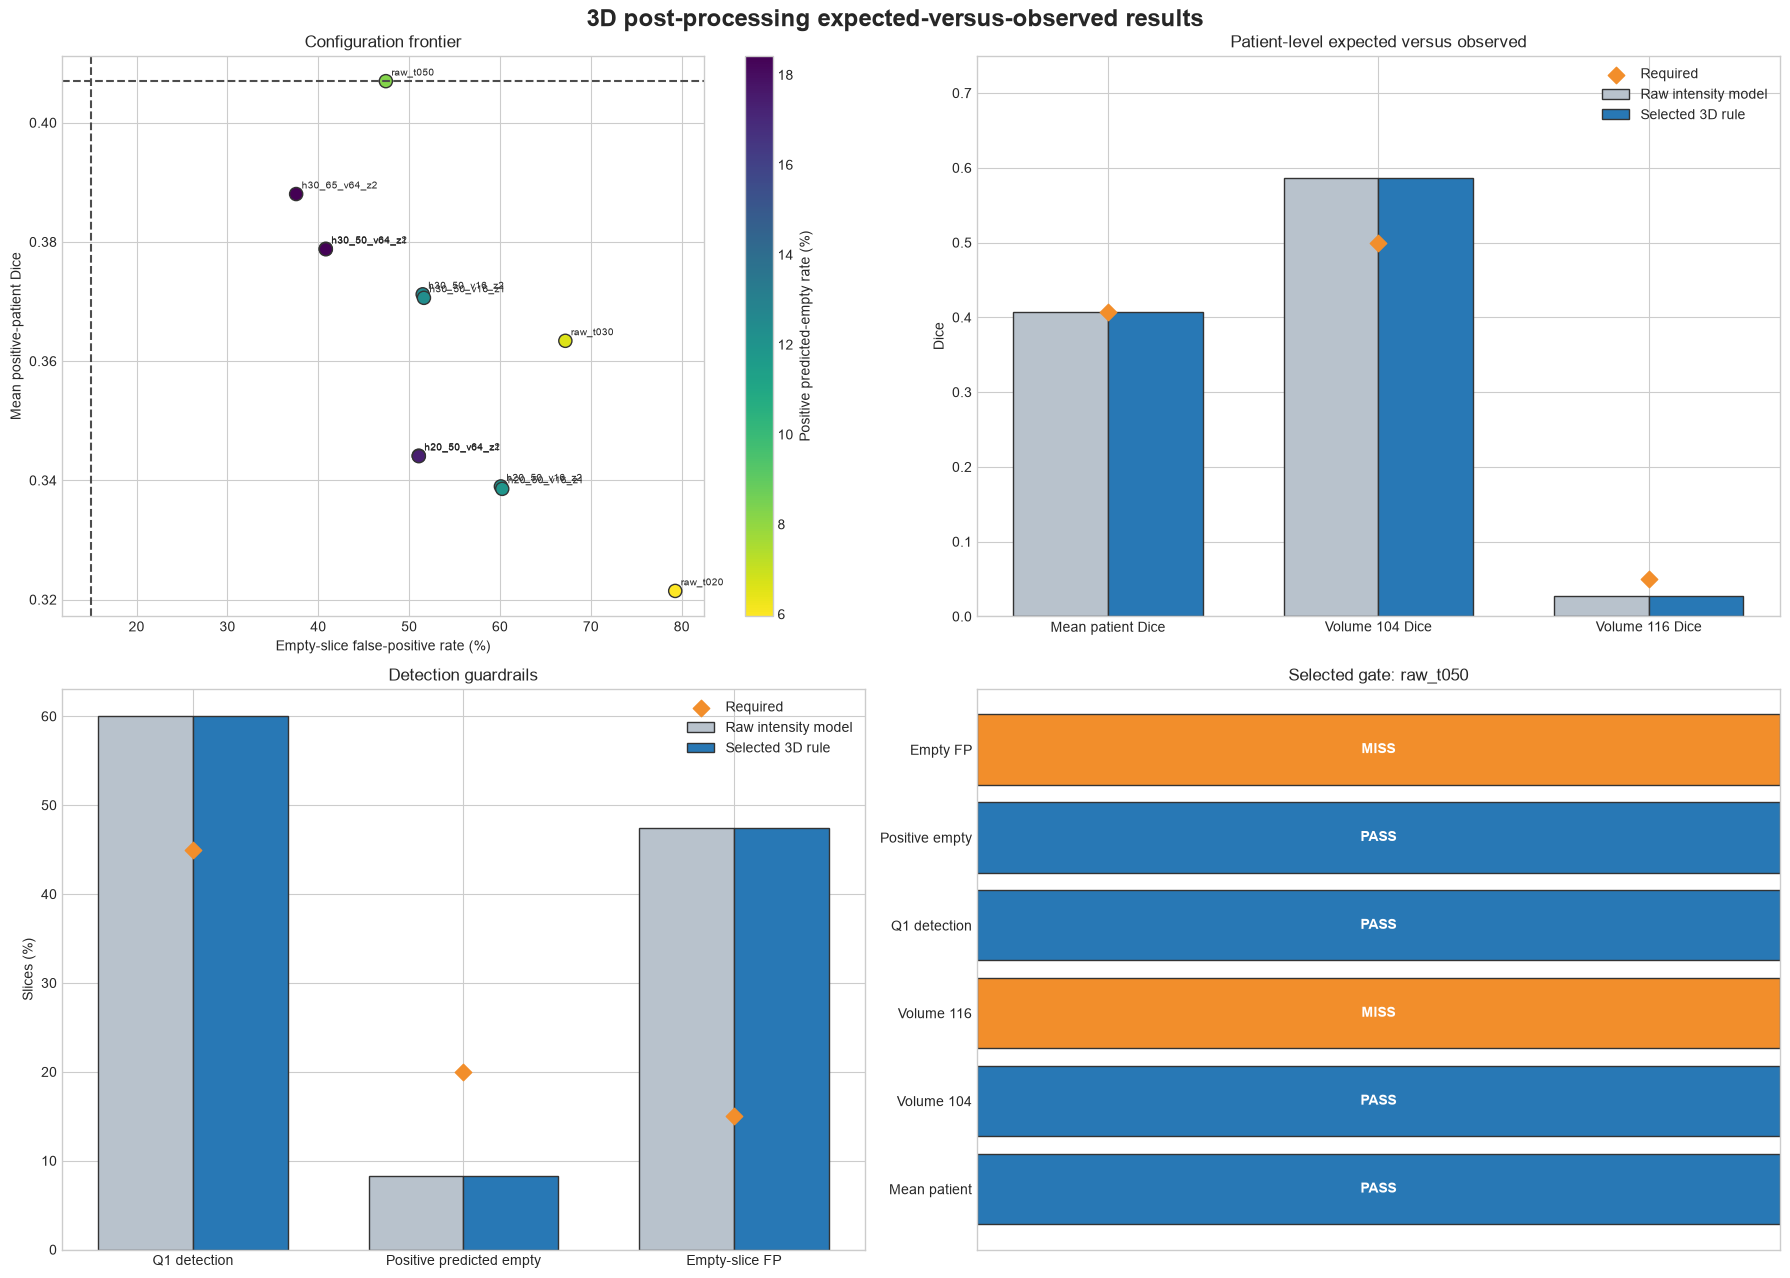

In [8]:
selected = summary.loc[summary["config"].eq(selected_config)].iloc[0]
raw = summary.loc[summary["config"].eq("raw_t050")].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
scatter = axes[0, 0].scatter(
    summary["empty_slice_false_positive_pct"], summary["mean_patient_dice"],
    c=summary["positive_predicted_empty_pct"], cmap="viridis_r",
    s=90, edgecolor="#333333",
)
for _, row in summary.iterrows():
    axes[0, 0].annotate(row["config"], (row["empty_slice_false_positive_pct"],
                                       row["mean_patient_dice"]),
                        xytext=(4, 4), textcoords="offset points", fontsize=7)
axes[0, 0].axvline(TARGETS["empty_slice_false_positive_pct"], linestyle="--", color="#4D4D4D")
axes[0, 0].axhline(TARGETS["mean_patient_dice"], linestyle="--", color="#4D4D4D")
axes[0, 0].set_title("Configuration frontier")
axes[0, 0].set_xlabel("Empty-slice false-positive rate (%)")
axes[0, 0].set_ylabel("Mean positive-patient Dice")
fig.colorbar(scatter, ax=axes[0, 0], label="Positive predicted-empty rate (%)")

comparison_metrics = [
    ("mean_patient_dice", "Mean patient Dice"),
    ("volume_104_dice", "Volume 104 Dice"),
    ("volume_116_dice", "Volume 116 Dice"),
]
x = np.arange(len(comparison_metrics)); width = 0.35
axes[0, 1].bar(x-width/2, [raw[k] for k, _ in comparison_metrics],
               width, label="Raw intensity model", color="#B8C2CC", edgecolor="#333333")
axes[0, 1].bar(x+width/2, [selected[k] for k, _ in comparison_metrics],
               width, label="Selected 3D rule", color="#2878B5", edgecolor="#333333")
axes[0, 1].scatter(x, [TARGETS[k] for k, _ in comparison_metrics],
                   marker="D", s=70, color="#F28E2B", label="Required")
axes[0, 1].set_xticks(x, [label for _, label in comparison_metrics])
axes[0, 1].set_ylim(0, 0.75); axes[0, 1].set_title("Patient-level expected versus observed")
axes[0, 1].set_ylabel("Dice"); axes[0, 1].legend()

rate_metrics = [
    ("q1_detected_pct", "Q1 detection", "higher"),
    ("positive_predicted_empty_pct", "Positive predicted empty", "lower"),
    ("empty_slice_false_positive_pct", "Empty-slice FP", "lower"),
]
x = np.arange(len(rate_metrics))
axes[1, 0].bar(x-width/2, [raw[k] for k, _, _ in rate_metrics],
               width, label="Raw intensity model", color="#B8C2CC", edgecolor="#333333")
axes[1, 0].bar(x+width/2, [selected[k] for k, _, _ in rate_metrics],
               width, label="Selected 3D rule", color="#2878B5", edgecolor="#333333")
axes[1, 0].scatter(x, [TARGETS[k] for k, _, _ in rate_metrics],
                   marker="D", s=70, color="#F28E2B", label="Required")
axes[1, 0].set_xticks(x, [label for _, label, _ in rate_metrics])
axes[1, 0].set_ylabel("Slices (%)"); axes[1, 0].set_title("Detection guardrails")
axes[1, 0].legend()

target_labels = [
    "Mean patient", "Volume 104", "Volume 116",
    "Q1 detection", "Positive empty", "Empty FP",
]
selected_pass = [bool(selected[column]) for column in pass_columns]
axes[1, 1].barh(target_labels, [1]*len(target_labels),
                color=["#2878B5" if value else "#F28E2B" for value in selected_pass],
                edgecolor="#333333")
for index, passed in enumerate(selected_pass):
    axes[1, 1].text(0.5, index, "PASS" if passed else "MISS",
                    ha="center", va="center", color="white", weight="bold")
axes[1, 1].set_xlim(0, 1); axes[1, 1].set_xticks([])
axes[1, 1].set_title(f"Selected gate: {selected_config}")

fig.suptitle("3D post-processing expected-versus-observed results", fontsize=17, weight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "expected_vs_actual_dashboard.png", dpi=170, bbox_inches="tight")
plt.show()

### 8. Patient response, lesion-size response, and axial persistence

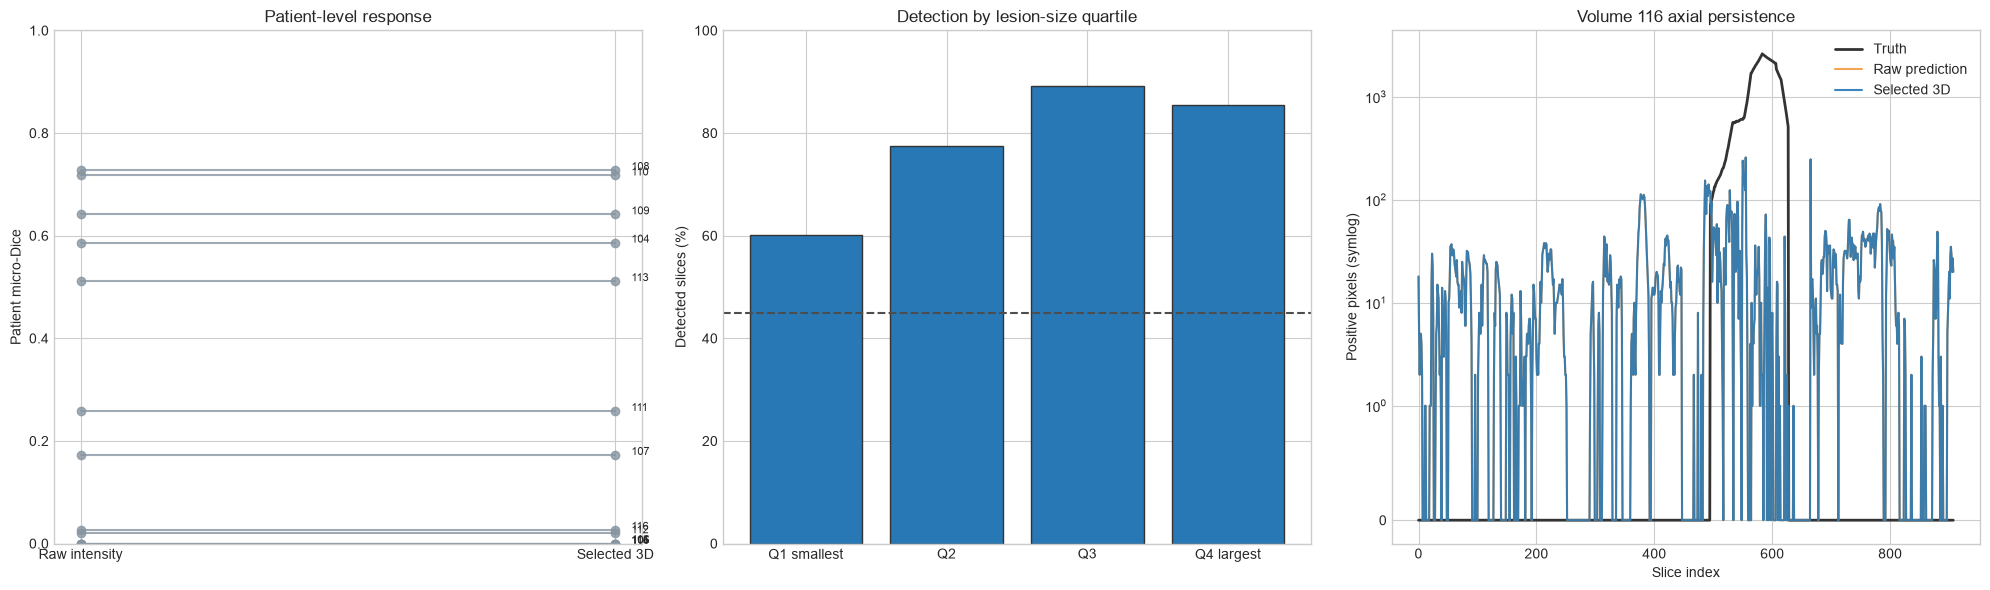

,size_quartile,slices,mean_dice,median_dice,detected_pct,predicted_empty_pct
0,Q1 smallest,263,0.322060,0.270270,60.076046,16.730038
1,Q2,258,0.443780,0.553709,77.519380,5.426357
2,Q3,260,0.582983,0.717432,89.230769,1.923077
3,Q4 largest,261,0.544885,0.718877,85.440613,8.812261


In [9]:
selected_patients = patient_results.loc[
    patient_results["config"].isin(["raw_t050", selected_config])
].copy()
pivot_patients = selected_patients.pivot(
    index="volume_id", columns="config", values="micro_dice"
).reset_index()
selected_slices = slice_results.loc[slice_results["config"].eq(selected_config)].copy()
positive_selected = selected_slices.loc[selected_slices["true_pixels"].gt(0)].copy()
positive_selected["size_quartile"] = pd.qcut(
    positive_selected["true_pixels"], q=4,
    labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"], duplicates="drop"
)
size_summary = positive_selected.groupby("size_quartile", observed=True).agg(
    slices=("sample_id", "size"),
    mean_dice=("dice", "mean"),
    median_dice=("dice", "median"),
    detected_pct=("intersection_pixels", lambda values: 100*(values > 0).mean()),
    predicted_empty_pct=("predicted_pixels", lambda values: 100*(values == 0).mean()),
).reset_index()
size_summary.to_csv(OUTPUT_DIR / "selected_size_quartiles.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for _, row in pivot_patients.iterrows():
    axes[0].plot([0, 1], [row["raw_t050"], row[selected_config]],
                 marker="o", color="#8795A1", alpha=0.8)
    axes[0].text(1.03, row[selected_config], str(int(row["volume_id"])), fontsize=8)
axes[0].set_xticks([0, 1], ["Raw intensity", "Selected 3D"])
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Patient micro-Dice")
axes[0].set_title("Patient-level response")

axes[1].bar(size_summary["size_quartile"].astype(str), size_summary["detected_pct"],
            color="#2878B5", edgecolor="#333333")
axes[1].axhline(TARGETS["q1_detected_pct"], linestyle="--", color="#4D4D4D")
axes[1].set_ylim(0, 100); axes[1].set_ylabel("Detected slices (%)")
axes[1].set_title("Detection by lesion-size quartile")

focus_volume = 116
with np.load(CACHE_DIR / f"volume_{focus_volume:03d}.npz") as data:
    probability = data["probability"].astype(np.float32) / 255.0
    truth_burden = data["truth"].sum(axis=(1, 2))
    raw_burden = (probability >= 0.5).sum(axis=(1, 2))
    config_row = configurations.set_index("config").loc[selected_config]
    selected_prediction = postprocess_volume(
        probability, config_row["low"], config_row["high"],
        int(config_row["min_voxels"]), int(config_row["min_z_span"]),
    )
    selected_burden = selected_prediction.sum(axis=(1, 2))
    slice_axis = data["slice_index"]
axes[2].plot(slice_axis, truth_burden, label="Truth", color="#333333", linewidth=2)
axes[2].plot(slice_axis, raw_burden, label="Raw prediction", color="#F28E2B", alpha=0.8)
axes[2].plot(slice_axis, selected_burden, label="Selected 3D", color="#2878B5", alpha=0.9)
axes[2].set_yscale("symlog", linthresh=1)
axes[2].set_xlabel("Slice index"); axes[2].set_ylabel("Positive pixels (symlog)")
axes[2].set_title("Volume 116 axial persistence"); axes[2].legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "patient_size_and_persistence.png", dpi=170, bbox_inches="tight")
plt.show()
display(size_summary)

### 9. Visual prediction audit: expected mask versus raw and selected outputs

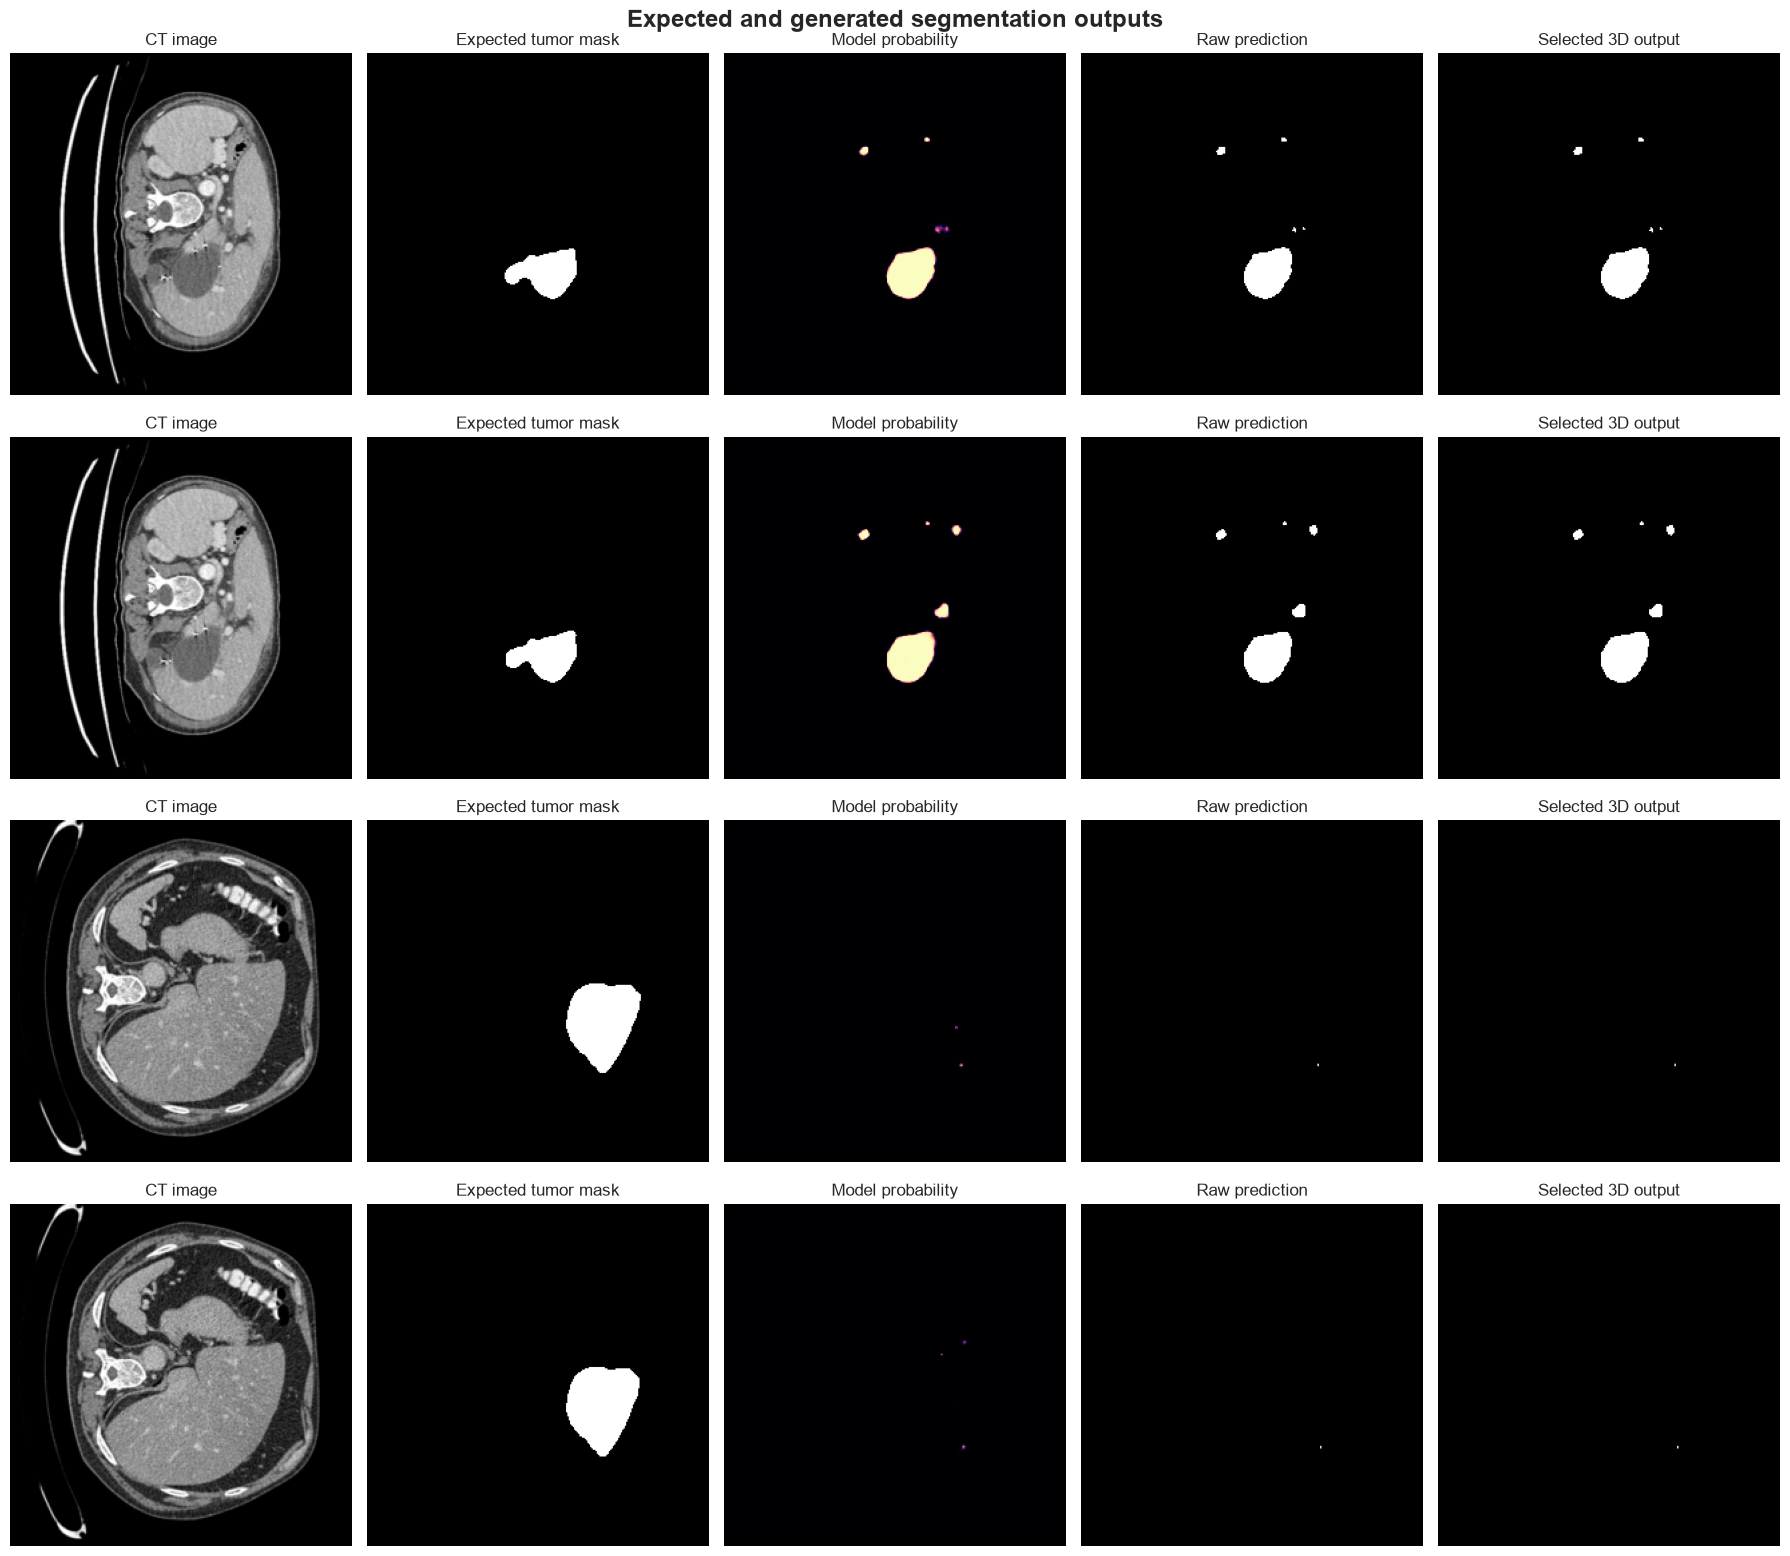

In [10]:
focus_cases = []
selected_rows = selected_slices.loc[selected_slices["true_pixels"].gt(0)].copy()
selected_rows["error_pixels"] = (
    selected_rows["true_pixels"] + selected_rows["predicted_pixels"]
    - 2 * selected_rows["intersection_pixels"]
)
for volume_id in [104, 116]:
    candidates = selected_rows.loc[selected_rows["volume_id"].eq(volume_id)]
    if len(candidates):
        focus_cases.extend(candidates.nlargest(2, "true_pixels")["sample_id"].tolist())
focus_cases.extend(selected_rows.nlargest(2, "error_pixels")["sample_id"].tolist())
focus_cases = list(dict.fromkeys(focus_cases))[:6]

row_lookup = {
    str(row["sample_id"]): row for row in val_base_dataset.rows
}
fig, axes = plt.subplots(len(focus_cases), 5, figsize=(18, 4*len(focus_cases)))
if len(focus_cases) == 1:
    axes = axes[None, :]
config_row = configurations.set_index("config").loc[selected_config]
for row_axes, sample_id in zip(axes, focus_cases):
    row = row_lookup[sample_id]
    volume_id = int(row["volume_id"])
    with np.load(CACHE_DIR / f"volume_{volume_id:03d}.npz") as data:
        match = np.flatnonzero(data["sample_id"] == sample_id)
        assert len(match) == 1
        index = int(match[0])
        probability_volume = data["probability"].astype(np.float32) / 255.0
        selected_volume = postprocess_volume(
            probability_volume, config_row["low"], config_row["high"],
            int(config_row["min_voxels"]), int(config_row["min_z_span"]),
        )
        probability = probability_volume[index]
        truth = data["truth"][index].astype(bool)
        raw_prediction = probability >= 0.5
        selected_prediction = selected_volume[index]
    with Image.open(row["image_path"]) as handle:
        image = np.asarray(handle.convert("L"), dtype=np.float32) / 255.0
    panels = [
        (image, "CT image", "gray", 0, 1),
        (truth, "Expected tumor mask", "gray", 0, 1),
        (probability, "Model probability", "magma", 0, 1),
        (raw_prediction, "Raw prediction", "gray", 0, 1),
        (selected_prediction, "Selected 3D output", "gray", 0, 1),
    ]
    for axis, (panel, title, cmap, vmin, vmax) in zip(row_axes, panels):
        axis.imshow(panel, cmap=cmap, vmin=vmin, vmax=vmax)
        axis.set_title(title); axis.axis("off")
    row_axes[0].set_ylabel(f"V{volume_id} | {sample_id}", fontsize=9)
fig.suptitle("Expected and generated segmentation outputs", fontsize=17, weight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "prediction_expected_vs_generated.png", dpi=170, bbox_inches="tight")
plt.show()

## Takeaways

### 10. Final gate and next-step recommendation

In [11]:
selected = summary.loc[summary["config"].eq(selected_config)].iloc[0]
gate_passed = bool(selected["all_targets_passed"])
result = {
    "status": "validation_3d_postprocessing_pass" if gate_passed else "validation_3d_postprocessing_fail",
    "manifest_sha256": manifest_hash,
    "checkpoint_sha256": checkpoint_hash,
    "source_model": "organ_robust_zscore_clip3_gamma_noise_v1",
    "selected_configuration": selected_config,
    "mean_patient_dice": float(selected["mean_patient_dice"]),
    "volume_104_dice": float(selected["volume_104_dice"]),
    "volume_116_dice": float(selected["volume_116_dice"]),
    "q1_detected_pct": float(selected["q1_detected_pct"]),
    "positive_predicted_empty_pct": float(selected["positive_predicted_empty_pct"]),
    "empty_slice_false_positive_pct": float(selected["empty_slice_false_positive_pct"]),
    "targets_passed": int(selected["targets_passed"]),
    "all_expected_targets_passed": gate_passed,
    "test_images_accessed": False,
    "decision": (
        "PASS — freeze the selected 3D rule and run one final locked-test evaluation."
        if gate_passed else
        "FAIL — do not open test; next experiment should learn liver/tumor localization rather than add another heuristic."
    ),
}
(OUTPUT_DIR / "validation_3d_postprocessing_gate_result.json").write_text(
    json.dumps(result, indent=2)
)
display(pd.DataFrame([result]).T.rename(columns={0: "value"}))
print(result["decision"])

,value
status,validation_3d_postprocessing_fail
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
checkpoint_sha256,5f18223c0f618d45d1433dc4a48d950fdea8a039db9ea5...
source_model,organ_robust_zscore_clip3_gamma_noise_v1
selected_configuration,raw_t050
mean_patient_dice,0.406964
volume_104_dice,0.586555
volume_116_dice,0.026794
q1_detected_pct,60.076046
positive_predicted_empty_pct,8.253359


FAIL — do not open test; next experiment should learn liver/tumor localization rather than add another heuristic.


### Interpretation guide

- **Pass:** freeze the checkpoint, preprocessing, threshold, and selected 3D configuration before requesting a single locked-test evaluation.
- **Fail because false positives remain high:** the next experiment should use learned liver localization or a multi-task liver/tumor model.
- **Fail because volume 116 and Q1 recall remain low:** post-processing cannot create missing signal; change representation or supervision rather than tightening thresholds.
- **Do not compare this validation-selected result directly with test performance as if it were unbiased.**